In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
print("Libraries loaded. Random seed fixed at", RANDOM_SEED)


Libraries loaded. Random seed fixed at 42


In [2]:
def simulate_district_series(n_weeks=471, base_level=140, trend=-0.03, seasonal_amp=18,
                              ar_coef=0.55, noise_sd=9, covid_drop=-28, start="2016-01-04",
                              seed=0):
    """Simulate a weekly reported-incident count series with trend, seasonality,
    a COVID-period structural break, and AR(1)-type persistence in the noise."""
    local_rng = np.random.default_rng(seed)
    dates = pd.date_range(start=start, periods=n_weeks, freq="W-MON")

    t = np.arange(n_weeks)
    trend_component = base_level + trend * t
    seasonal_component = seasonal_amp * np.sin(2 * np.pi * t / 52.18)

    # COVID structural break: step down starting the week nearest 2020-03-16
    covid_start = dates.get_indexer([pd.Timestamp("2020-03-16")], method="nearest")[0]
    break_component = np.where(t >= covid_start, covid_drop, 0.0)
    # partial recovery drift after the break
    recovery = np.where(t >= covid_start, 0.04 * (t - covid_start), 0.0)
    recovery = np.minimum(recovery, -covid_drop * 0.6)

    # AR(1) innovations for realistic autocorrelation
    eps = local_rng.normal(0, noise_sd, size=n_weeks)
    ar_noise = np.zeros(n_weeks)
    for i in range(1, n_weeks):
        ar_noise[i] = ar_coef * ar_noise[i - 1] + eps[i]
    ar_noise[0] = eps[0]

    values = trend_component + seasonal_component + break_component + recovery + ar_noise
    values = np.maximum(np.round(values), 0).astype(int)  # non-negative integer counts

    return pd.Series(values, index=dates, name="incident_count")

district1 = simulate_district_series(base_level=118, trend=-0.028, seasonal_amp=14,
                                      ar_coef=0.50, noise_sd=7.5, covid_drop=-22, seed=1)
district12 = simulate_district_series(base_level=205, trend=-0.02, seasonal_amp=24,
                                       ar_coef=0.42, noise_sd=13.0, covid_drop=-35, seed=12)

district1.index.name = "week_start"
district12.index.name = "week_start"

crime_weekly = pd.DataFrame({"District 1": district1, "District 12": district12})
print(f"Series length: {len(crime_weekly)} weeks each, {crime_weekly.index.min().date()} to {crime_weekly.index.max().date()}")
crime_weekly.head()


Series length: 471 weeks each, 2016-01-04 to 2025-01-06


,District 1,District 12
week_start,,
2016-01-04,121,205
2016-01-11,126,221
2016-01-18,127,226
2016-01-25,116,229
2016-02-01,128,244


In [3]:
N_TEST = 12

train1, test1 = district1.iloc[:-N_TEST], district1.iloc[-N_TEST:]
train12, test12 = district12.iloc[:-N_TEST], district12.iloc[-N_TEST:]

print(f"District 1  -> train: {len(train1)} weeks, test: {len(test1)} weeks (locked)")
print(f"District 12 -> train: {len(train12)} weeks, test: {len(test12)} weeks (locked)")
print()
print("Test window:", test1.index.min().date(), "to", test1.index.max().date())


District 1  -> train: 459 weeks, test: 12 weeks (locked)
District 12 -> train: 459 weeks, test: 12 weeks (locked)

Test window: 2024-10-21 to 2025-01-06


## 4. Exploratory Analysis and Descriptive Statistics

In [4]:
desc = crime_weekly.describe().T
desc["cv"] = desc["std"] / desc["mean"]
desc


,count,mean,std,min,25%,50%,75%,max,cv
District 1,471.0,101.652,16.988,63.0,88.5,101.0,114.0,145.0,0.167
District 12,471.0,184.463,28.820,118.0,164.0,184.0,203.5,261.0,0.156


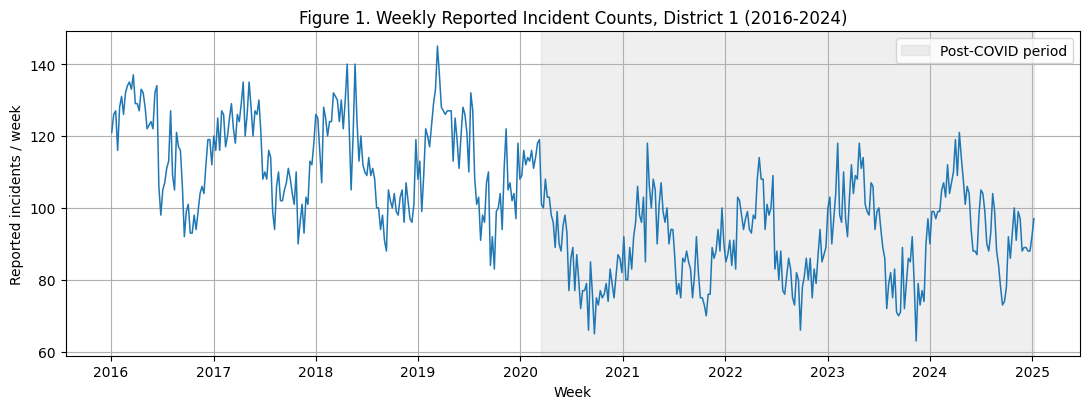

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(district1.index, district1.values, color="#1f77b4", lw=1.1)
ax.axvspan(pd.Timestamp("2020-03-16"), district1.index.max(), color="grey", alpha=0.12,
           label="Post-COVID period")
ax.set_title("Figure 1. Weekly Reported Incident Counts, District 1 (2016-2024)")
ax.set_xlabel("Week")
ax.set_ylabel("Reported incidents / week")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


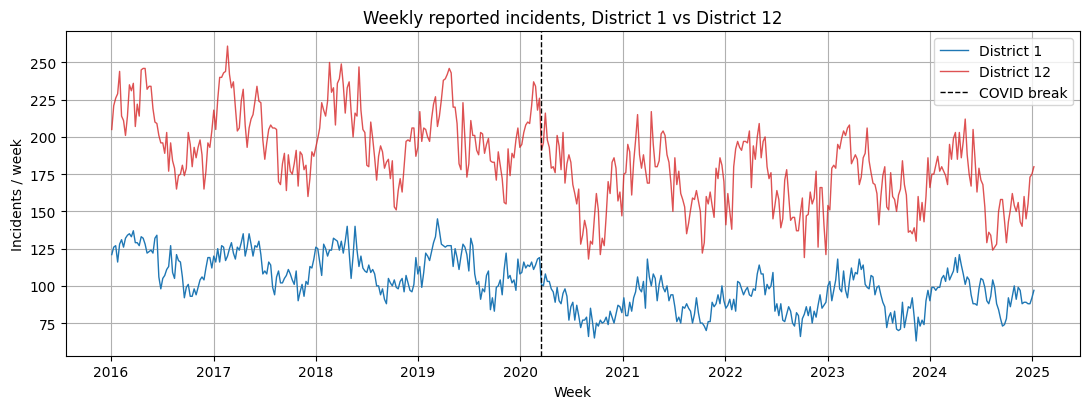

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(district1.index, district1.values, label="District 1", color="#1f77b4", lw=1.0)
ax.plot(district12.index, district12.values, label="District 12", color="#d62728", lw=1.0, alpha=0.8)
ax.axvline(pd.Timestamp("2020-03-16"), color="black", linestyle="--", lw=1, label="COVID break")
ax.set_title("Weekly reported incidents, District 1 vs District 12")
ax.set_xlabel("Week"); ax.set_ylabel("Incidents / week")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Stationarity Diagnostics — Augmented Dickey-Fuller (training data only)

In [7]:
def run_adf(series, label):
    result = adfuller(series, autolag="AIC")
    print(f"ADF test — {label}")
    print(f"  Test statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags used      : {result[2]}")
    for k, v in result[4].items():
        print(f"  Critical value ({k}): {v:.3f}")
    verdict = "REJECT unit root (stationary)" if result[1] < 0.05 else "CANNOT reject unit root (non-stationary)"
    print(f"  Verdict @5%    : {verdict}\n")
    return result

adf_d1 = run_adf(train1, "District 1 (training)")
adf_d12 = run_adf(train12, "District 12 (training)")


ADF test — District 1 (training)
  Test statistic : -2.8500
  p-value        : 0.0515
  Lags used      : 3
  Critical value (1%): -3.445
  Critical value (5%): -2.868
  Critical value (10%): -2.570
  Verdict @5%    : CANNOT reject unit root (non-stationary)

ADF test — District 12 (training)
  Test statistic : -3.6235
  p-value        : 0.0053
  Lags used      : 3
  Critical value (1%): -3.445
  Critical value (5%): -2.868
  Critical value (10%): -2.570
  Verdict @5%    : REJECT unit root (stationary)



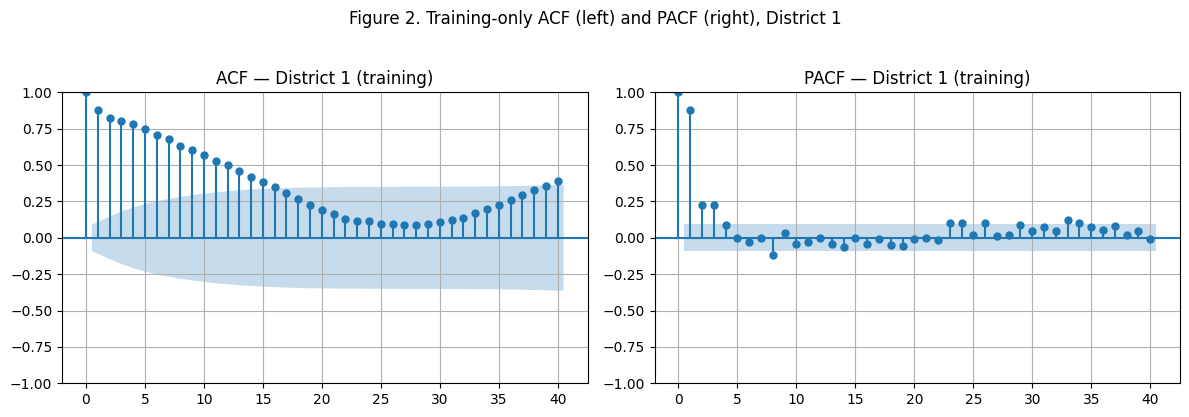

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(train1, lags=40, ax=axes[0], title="ACF — District 1 (training)")
plot_pacf(train1, lags=40, ax=axes[1], method="ywm", title="PACF — District 1 (training)")
fig.suptitle("Figure 2. Training-only ACF (left) and PACF (right), District 1", y=1.03)
plt.tight_layout()
plt.show()


In [9]:
def arima_grid_search(train_series, p_range=range(0, 4), d_range=range(0, 2), q_range=range(0, 4)):
    results = []
    for p in p_range:
        for d in d_range:
            for q in q_range:
                if p == 0 and q == 0:
                    continue
                try:
                    model = ARIMA(train_series, order=(p, d, q),
                                   enforce_stationarity=False, enforce_invertibility=False)
                    fit = model.fit()
                    results.append({"order": (p, d, q), "AIC": fit.aic, "BIC": fit.bic})
                except Exception:
                    continue
    return pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)

grid_d1 = arima_grid_search(train1)
grid_d12 = arima_grid_search(train12)

best_order_d1 = grid_d1.iloc[0]["order"]
best_order_d12 = grid_d12.iloc[0]["order"]

print("Top 5 candidate orders — District 1:")
print(grid_d1.head(5).to_string(index=False))
print(f"\nSelected order (min AIC), District 1  : {best_order_d1}  (AIC={grid_d1.iloc[0]['AIC']:.2f})")

print("\nTop 5 candidate orders — District 12:")
print(grid_d12.head(5).to_string(index=False))
print(f"\nSelected order (min AIC), District 12 : {best_order_d12}  (AIC={grid_d12.iloc[0]['AIC']:.2f})")


Top 5 candidate orders — District 1:
    order      AIC      BIC
(0, 1, 3) 3152.093 3168.565
(1, 1, 3) 3152.845 3173.436
(2, 0, 3) 3153.102 3181.944
(3, 0, 3) 3154.872 3187.835
(2, 1, 3) 3155.029 3179.737

Selected order (min AIC), District 1  : (0, 1, 3)  (AIC=3152.09)

Top 5 candidate orders — District 12:
    order      AIC      BIC
(0, 1, 3) 3731.445 3747.918
(1, 0, 3) 3732.077 3756.799
(1, 1, 3) 3732.877 3753.468
(3, 0, 3) 3733.938 3766.900
(2, 0, 3) 3734.078 3762.920

Selected order (min AIC), District 12 : (0, 1, 3)  (AIC=3731.45)


In [10]:
AR_LAGS = 4

def fit_models(train_series, best_order):
    ar_fit = AutoReg(train_series, lags=AR_LAGS, trend="ct").fit()
    arima_fit = ARIMA(train_series, order=best_order,
                       enforce_stationarity=False, enforce_invertibility=False).fit()
    return ar_fit, arima_fit

ar_fit_d1, arima_fit_d1 = fit_models(train1, best_order_d1)
ar_fit_d12, arima_fit_d12 = fit_models(train12, best_order_d12)

print(f"District 1  — AR({AR_LAGS}) AIC: {ar_fit_d1.aic:.2f} | ARIMA{tuple(best_order_d1)} AIC: {arima_fit_d1.aic:.2f}")
print(f"District 12 — AR({AR_LAGS}) AIC: {ar_fit_d12.aic:.2f} | ARIMA{tuple(best_order_d12)} AIC: {arima_fit_d12.aic:.2f}")


District 1  — AR(4) AIC: 3150.78 | ARIMA(0, 1, 3) AIC: 3152.09
District 12 — AR(4) AIC: 3725.34 | ARIMA(0, 1, 3) AIC: 3731.45


In [11]:
def naive_forecast(train_series, horizon):
    """Persistence baseline: repeat the last observed training value."""
    return pd.Series(np.repeat(train_series.iloc[-1], horizon))

def evaluate(actual, forecast):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast) ** 2))
    return mae, rmse

def forecast_all(train_series, test_series, ar_fit, arima_fit, ar_lags=AR_LAGS):
    h = len(test_series)
    naive_fc = naive_forecast(train_series, h).values
    ar_fc = ar_fit.predict(start=len(train_series), end=len(train_series) + h - 1).values
    arima_fc = arima_fit.forecast(steps=h).values
    return naive_fc, ar_fc, arima_fc

naive_fc1, ar_fc1, arima_fc1 = forecast_all(train1, test1, ar_fit_d1, arima_fit_d1)
naive_fc12, ar_fc12, arima_fc12 = forecast_all(train12, test12, ar_fit_d12, arima_fit_d12)

rows = []
for name, actual, naive_fc, ar_fc, arima_fc, order in [
        ("District 1", test1, naive_fc1, ar_fc1, arima_fc1, best_order_d1),
        ("District 12", test12, naive_fc12, ar_fc12, arima_fc12, best_order_d12)]:
    for model_name, fc in [("Naive persistence", naive_fc), (f"AR({AR_LAGS})", ar_fc),
                            (f"ARIMA{tuple(order)}", arima_fc)]:
        mae, rmse = evaluate(actual.values, fc)
        rows.append({"District": name, "Model": model_name, "MAE": mae, "RMSE": rmse})

results_table = pd.DataFrame(rows)
results_table.pivot(index="Model", columns="District", values=["MAE", "RMSE"]).round(2)


MAE                   RMSE            
District          District 1 District 12 District 1 District 12
Model                                                          
AR(4)                   8.24       11.19       9.29       13.77
ARIMA(0, 1, 3)          7.88       13.07       9.01       16.64
Naive persistence       6.58       11.08       7.89       14.07

In [12]:
best_by_district = results_table.loc[results_table.groupby("District")["MAE"].idxmin()]
print("Best model per district (by locked-test MAE):")
best_by_district[["District", "Model", "MAE", "RMSE"]].to_string(index=False)


Best model per district (by locked-test MAE):


'   District             Model    MAE   RMSE\n District 1 Naive persistence  6.583  7.890\nDistrict 12 Naive persistence 11.083 14.068'

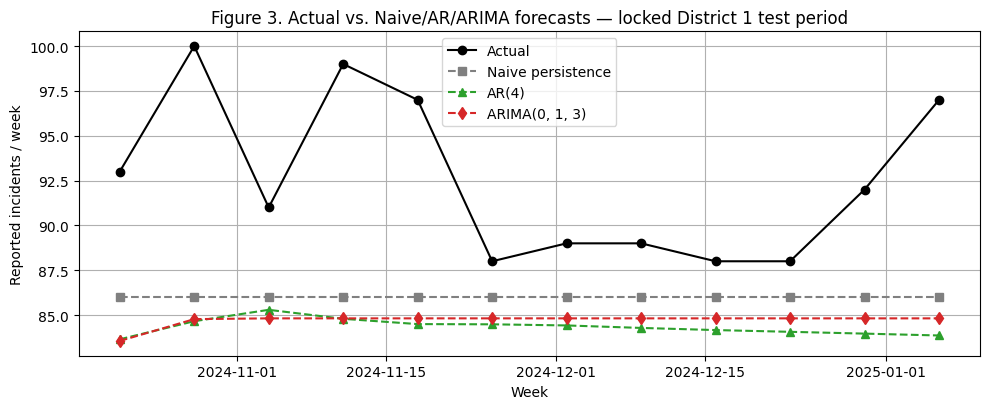

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(test1.index, test1.values, "o-", color="black", label="Actual", lw=1.5)
ax.plot(test1.index, naive_fc1, "s--", color="grey", label="Naive persistence")
ax.plot(test1.index, ar_fc1, "^--", color="#2ca02c", label=f"AR({AR_LAGS})")
ax.plot(test1.index, arima_fc1, "d--", color="#d62728", label=f"ARIMA{tuple(best_order_d1)}")
ax.set_title("Figure 3. Actual vs. Naive/AR/ARIMA forecasts — locked District 1 test period")
ax.set_xlabel("Week"); ax.set_ylabel("Reported incidents / week")
ax.legend()
plt.tight_layout()
plt.show()


In [14]:
resid_d1 = arima_fit_d1.resid

lb_test = acorr_ljungbox(resid_d1, lags=[10], return_df=True)
print("Ljung-Box test on District 1 ARIMA residuals (lag 10):")
print(lb_test)
lb_stat = lb_test['lb_stat'].iloc[0]
lb_p = lb_test['lb_pvalue'].iloc[0]
verdict = "residuals ARE consistent with white noise (fail to reject H0)" if lb_p >= 0.05 \
          else "residual autocorrelation DETECTED (reject H0)"
print(f"\nLjung-Box statistic = {lb_stat:.3f}, p-value = {lb_p:.4f} -> {verdict}")


Ljung-Box test on District 1 ARIMA residuals (lag 10):
    lb_stat  lb_pvalue
10    6.705      0.753

Ljung-Box statistic = 6.705, p-value = 0.7530 -> residuals ARE consistent with white noise (fail to reject H0)


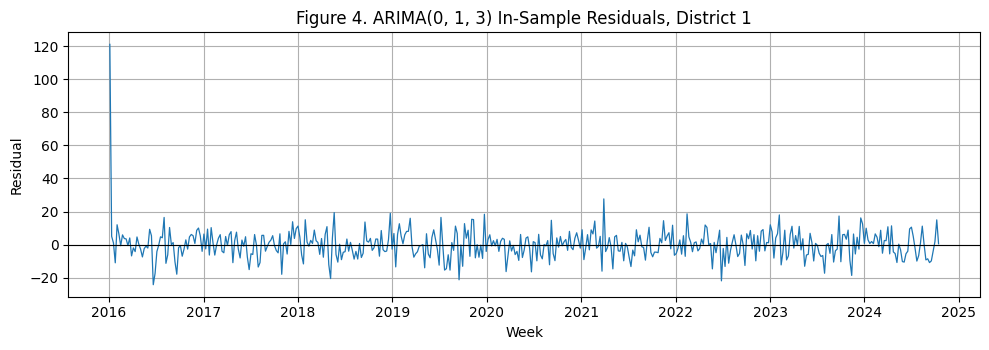

In [15]:
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(resid_d1.index, resid_d1.values, color="#1f77b4", lw=0.9)
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Figure 4. ARIMA{tuple(best_order_d1)} In-Sample Residuals, District 1")
ax.set_xlabel("Week"); ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()


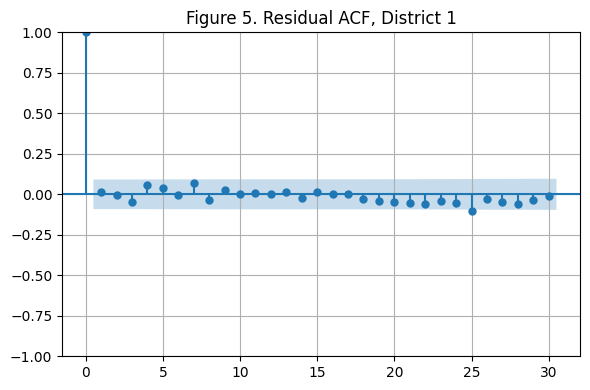

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_acf(resid_d1, lags=30, ax=ax, title="Figure 5. Residual ACF, District 1")
plt.tight_layout()
plt.show()


In [17]:
def rolling_origin_backtest(series, order, horizon=8, step=8, min_train=200):
    n = len(series)
    fold_maes = []
    origin = min_train
    while origin + horizon <= n:
        train_fold = series.iloc[:origin]
        test_fold = series.iloc[origin: origin + horizon]
        try:
            fit = ARIMA(train_fold, order=order, enforce_stationarity=False,
                        enforce_invertibility=False).fit()
            fc = fit.forecast(steps=horizon).values
            mae, _ = evaluate(test_fold.values, fc)
            fold_maes.append(mae)
        except Exception:
            pass
        origin += step
    return np.array(fold_maes)

# training/validation history only (exclude the locked 12-week test set, already done via train1)
fold_maes = rolling_origin_backtest(train1, best_order_d1, horizon=8, step=8, min_train=200)

print(f"Rolling-origin backtest: {len(fold_maes)} folds, 8-week horizon, 8-week step")
print(f"Mean MAE = {fold_maes.mean():.2f}, SD = {fold_maes.std(ddof=1):.2f}")
print(f"Range    = {fold_maes.min():.2f} to {fold_maes.max():.2f}")


Rolling-origin backtest: 32 folds, 8-week horizon, 8-week step
Mean MAE = 9.08, SD = 3.70
Range    = 2.88 to 16.61


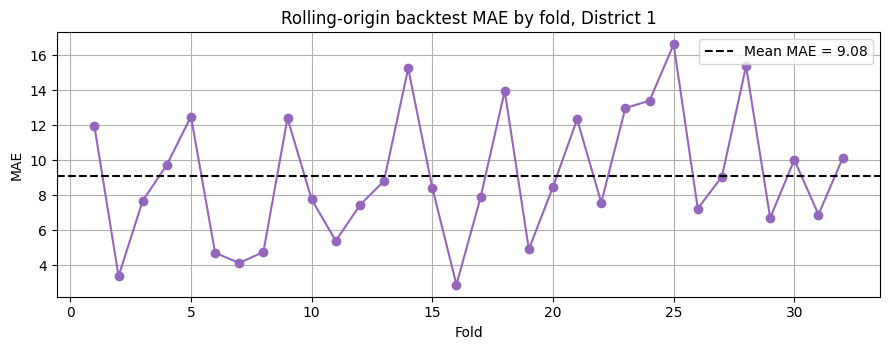

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(range(1, len(fold_maes) + 1), fold_maes, "o-", color="#9467bd")
ax.axhline(fold_maes.mean(), color="black", linestyle="--", label=f"Mean MAE = {fold_maes.mean():.2f}")
ax.set_title("Rolling-origin backtest MAE by fold, District 1")
ax.set_xlabel("Fold"); ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()
